In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.eda_utils import parse_money, binarize_target

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
CSV = ROOT / "SBAnational.csv"
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("csv exists:", CSV.exists())

csv exists: True


In [2]:
MONEY_COLS = ["DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"]
df = pd.read_csv(CSV, dtype=str, low_memory=False)
for c in MONEY_COLS:
    df[c] = parse_money(df[c])
for c in ["Term", "NoEmp", "CreateJob", "RetainedJob", "ApprovalFY", "FranchiseCode", "UrbanRural"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce", format="%d-%b-%y")
df["target"] = binarize_target(df["MIS_Status"])
print("shape:", df.shape)
df.head(3)

shape: (899164, 28)


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,target
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,1997-02-28,1997.0,84,4,2,0,0,1,0,N,Y,NaN,28-Feb-99,60000.0,0.0,P I F,0.0,60000.0,48000.0,0.0
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,1997-02-28,1997.0,60,2,2,0,0,1,0,N,Y,NaN,31-May-97,40000.0,0.0,P I F,0.0,40000.0,32000.0,0.0
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,1997-02-28,1997.0,180,7,1,0,0,1,0,N,N,NaN,31-Dec-97,287000.0,0.0,P I F,0.0,287000.0,215250.0,0.0


In [3]:
# NewExist 공식 정의: 1 = Existing business, 2 = New business
print(df["NewExist"].value_counts(dropna=False))
# 이상치(0)와 결측은 분석에서 제외 표시
df["is_new"] = df["NewExist"].map({"1": 0, "2": 1})  # 1=신규(New)
print("\nis_new(1=신규) 분포:")
print(df["is_new"].value_counts(dropna=False))

NewExist
1      644869
2      253125
0        1034
NaN       136
Name: count, dtype: int64

is_new(1=신규) 분포:
is_new
0.0    644869
1.0    253125
NaN      1170
Name: count, dtype: int64


In [4]:
chk = df.dropna(subset=["target"]).groupby("NewExist")["target"].agg(["mean", "size"])
print("NewExist별 부실률(target mean) / 건수:")
print(chk)

NewExist별 부실률(target mean) / 건수:
              mean    size
NewExist                  
0         0.061284    1028
1         0.171132  643446
2         0.187548  252559


In [5]:
miss = df.isna().mean().sort_values(ascending=False)
print("결측률 상위:")
print((miss[miss > 0] * 100).round(2).astype(str) + "%")


결측률 상위:
ChgOffDate          81.91%
RevLineCr             0.5%
LowDoc               0.29%
DisbursementDate     0.26%
target               0.22%
MIS_Status           0.22%
BankState            0.17%
Bank                 0.17%
is_new               0.13%
NewExist             0.02%
City                  0.0%
ApprovalFY            0.0%
Name                  0.0%
State                 0.0%
dtype: object


In [6]:
num_cols = ["GrAppv", "SBA_Appv", "Term", "NoEmp", "CreateJob", "RetainedJob"]
display(df[num_cols].describe(percentiles=[.01, .5, .99]).T)
print("Term==0:", (df["Term"] == 0).sum())
print("GrAppv<=0:", (df["GrAppv"] <= 0).sum())
print("NoEmp==0:", (df["NoEmp"] == 0).sum())


,count,mean,std,min,1%,50%,99%,max
GrAppv,899164.0,192686.976384,283263.391297,200.0,5000.0,90000.0,1350000.0,5472000.0
SBA_Appv,899164.0,149488.788175,228414.561519,100.0,2500.0,61250.0,1000000.0,5472000.0
Term,899164.0,110.773078,78.857305,0.0,5.0,84.0,300.0,569.0
NoEmp,899164.0,11.411353,74.108196,0.0,1.0,4.0,95.0,9999.0
CreateJob,899164.0,8.430376,236.688165,0.0,0.0,0.0,30.0,8800.0
RetainedJob,899164.0,10.797257,237.120600,0.0,0.0,1.0,55.0,9500.0


Term==0: 810
GrAppv<=0: 0
NoEmp==0: 6631


target
0.0    739609
1.0    157558
NaN      1997
Name: count, dtype: int64

부실률(CHGOFF=1): 0.1756
타깃 결측(분석 제외 대상): 1997


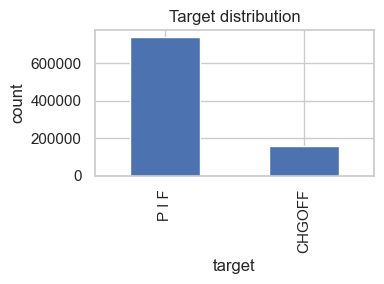

In [7]:
tgt = df["target"].value_counts(dropna=False)
print(tgt)
rate = df["target"].mean()
print(f"\n부실률(CHGOFF=1): {rate:.4f}")
print(f"타깃 결측(분석 제외 대상): {df['target'].isna().sum()}")

fig, ax = plt.subplots(figsize=(4, 3))
df["target"].dropna().map({0: "P I F", 1: "CHGOFF"}).value_counts().plot.bar(ax=ax)
ax.set_title("Target distribution"); ax.set_ylabel("count")
fig.tight_layout(); fig.savefig(FIG / "target_dist.png", dpi=120); plt.show()


In [8]:
d = df.dropna(subset=["target"]).copy()
d["naics2"] = df["NAICS"].str[:2]
by_naics = d.groupby("naics2")["target"].agg(["mean", "size"]).sort_values("mean", ascending=False)
by_naics = by_naics[by_naics["size"] >= 500]
display(by_naics.head(10))


,mean,size
naics2,,
53,0.287312,13588
52,0.284266,9470
48,0.268888,20198
51,0.248284,11362
61,0.242462,6401
56,0.235513,32529
45,0.234154,42408
23,0.232554,66492
49,0.229864,2210


In [9]:
by_state = d.groupby("State")["target"].agg(["mean", "size"]).sort_values("mean", ascending=False)
display(by_state[by_state["size"] >= 500].head(10))

d["grappv_bin"] = pd.qcut(d["GrAppv"], 5, duplicates="drop")
d["term_bin"] = pd.cut(d["Term"], bins=[-1, 0, 60, 120, 180, 1000])
print("\n승인액 5분위별 부실률:"); print(d.groupby("grappv_bin", observed=True)["target"].mean())
print("\nTerm 구간별 부실률:"); print(d.groupby("term_bin", observed=True)["target"].mean())


,mean,size
State,,
FL,0.273694,41192
DC,0.239926,1613
GA,0.239628,22272
NV,0.232236,8022
IL,0.226701,29594
MI,0.225052,20493
TN,0.212128,9400
AZ,0.207501,17624
SC,0.204647,5595



승인액 5분위별 부실률:
grappv_bin
(999.999, 25200.0]       0.288016
(25200.0, 57000.0]       0.234720
(57000.0, 121200.0]      0.151840
(121200.0, 287000.0]     0.113282
(287000.0, 5472000.0]    0.089914
Name: target, dtype: float64

Term 구간별 부실률:
term_bin
(-1, 0]        0.910670
(0, 60]        0.382343
(60, 120]      0.110423
(120, 180]     0.081744
(180, 1000]    0.033592
Name: target, dtype: float64


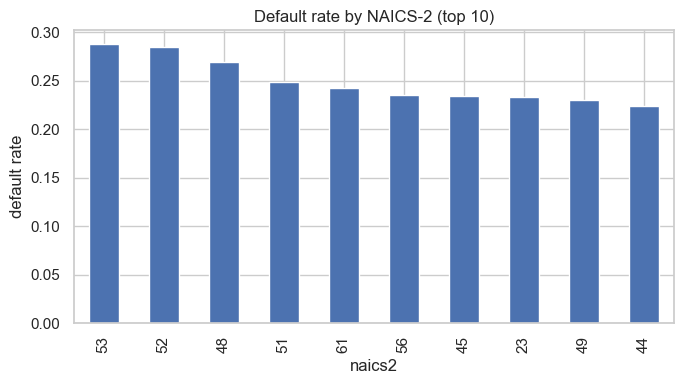

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
by_naics["mean"].head(10).plot.bar(ax=ax)
ax.set_title("Default rate by NAICS-2 (top 10)"); ax.set_ylabel("default rate")
fig.tight_layout(); fig.savefig(FIG / "default_by_naics2.png", dpi=120); plt.show()


In [11]:
seg = d.copy()
seg["segment"] = seg["is_new"].map({1: "New(thin-file proxy)", 0: "Existing"})
cmp = seg.dropna(subset=["segment"]).groupby("segment").agg(
    n=("target", "size"),
    default_rate=("target", "mean"),
    avg_grappv=("GrAppv", "mean"),
    avg_term=("Term", "mean"),
)
print("주의: New는 신용이력이 아닌 '사업운영이력' 짧음 기반 proxy임")
display(cmp)


주의: New는 신용이력이 아닌 '사업운영이력' 짧음 기반 proxy임


,n,default_rate,avg_grappv,avg_term
segment,,,,
Existing,643446,0.171132,204522.506360,114.383468
New(thin-file proxy),252559,0.187548,163285.078243,101.725062
